# Random forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import time



In [ ]:
#  Clean the dataset
def clean_dataset(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].notnull().any():
            q_low = df_clean[col].quantile(0.001)
            q_high = df_clean[col].quantile(0.999)
            df_clean[col] = df_clean[col].clip(lower=q_low, upper=q_high)
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    return df_clean

#  Load and preprocess
file_path = '../../car_data.csv'
df = pd.read_csv(file_path)
df = clean_dataset(df)

selected_columns = ['Cod_fasecolda', 'Modelo', 'Kilometraje', 'Year', 'Month', 'Ubicacion_int', 'Demanda', 'Promedio_estrellas', 'Combustible_int', 'Descripcion_int', 'Gama_int', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int', 'Estado_vitrina_int','Pricing']
print(df.columns.tolist())

df = df[[col for col in selected_columns if col in df.columns]]

print(df.shape)
# df = df.head(500)
# df = df.astype(float)
print(df.columns.tolist())

print(df.shape)
df['Modelo'] = df['Modelo'].replace('-', np.nan)
df = df.dropna(subset=['Modelo'])
df['Kilometraje'] = df['Kilometraje'].replace('-', 0)
df['Kilometraje'] = df['Kilometraje'].replace(r'[^\d.-]', '', regex=True)  # Elimina caracteres no numéricos

df['Kilometraje'] = pd.to_numeric(df['Kilometraje'], errors='coerce').fillna(0)  # Convierte a float
df['Pricing'] = pd.to_numeric(df['Pricing'], errors='coerce')
df = df.dropna(subset=['Pricing'])
for i in selected_columns:
    # print(i)
    df[i] = df[i].astype(float)

X = df.drop(columns=['Pricing'])
y = df['Pricing']
y_log = np.log1p(y)

print(df.shape)


/tmp/ipykernel_1450869/2740512710.py:15: DtypeWarning: Columns (2,9,27,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


['Unnamed: 0', 'Estado_vehiculo', 'Referencia_old', 'Fecha_venta', 'Modelo', 'Cod_fasecolda', 'Marca', 'Linea', 'Referencia', 'Kilometraje', 'Year', 'Month', 'Ubicacion', 'Ubicacion_int', 'MPIO_CDPMP', 'Servicio', 'Servicio_int', 'Estado_vitrina', 'Estado_vitrina_int', 'Gama', 'Gama_int', 'Group_number', 'Demanda', 'Sales', 'Promedio_estrellas', 'Combustible', 'Combustible_int', 'Descripcion', 'Descripcion_int', 'Blindaje', 'Estado_vehiculo_int', 'Pricing']
(1466681, 16)
['Cod_fasecolda', 'Modelo', 'Kilometraje', 'Year', 'Month', 'Ubicacion_int', 'Demanda', 'Promedio_estrellas', 'Combustible_int', 'Descripcion_int', 'Gama_int', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int', 'Estado_vitrina_int', 'Pricing']
(1466681, 16)
(1466677, 16)



Training Random Forest...
Random Forest training time: 65.76 seconds
Modelo Random Forest guardado como random_forest_model.pkl
 Random Forest
   RMSE: 7923759.55
   R²: 0.9675
   MAPE: inf%


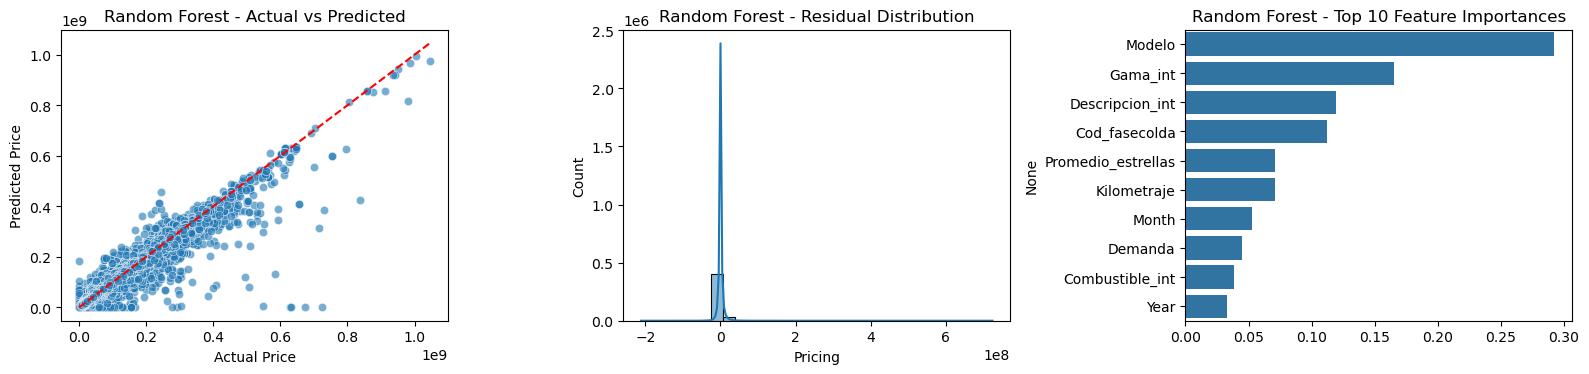

 Output saved as car_data_model_results.csv


: 

In [ ]:
# split the data

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.3, random_state=42)
y_test_orig = np.expm1(y_test)
# Defining the models
m_dep : int = 22
models = {
    'Random Forest' : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=m_dep),
    # 'XGBoost' : XGBRegressor(n_estimators=100, random_state=42, verbosity = 0, n_jobs=-1),
    # 'LightGBM' : LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, boosting_type='gbdt')
}

output_df = X_test.copy()
output_df['actual_pricing'] = y_test_orig 

for name, model in models.items():
    print(f'\nTraining {name}...')

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ]) 
    
    start = time.time()
    pipeline.fit(X_train, y_train)
    print(f"{name} training time: {(time.time() - start):.2f} seconds")

    # Guardar el modelo ya entrenado
    joblib.dump(pipeline, f'../{name.lower().replace(" ", "_")}_model_{m_dep}.pkl')
    print(f"Modelo {name} guardado como {name.lower().replace(' ', '_')}_model.pkl")

    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test_orig, y_pred)
    mape = np.mean(np.abs((y_test_orig - y_pred)/ y_test_orig)) * 100

    print(f" {name}")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   R²: {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")
    pred_col = f"{name.lower().replace(' ', '_')}_pred"
    resid_col = f"{name.lower().replace(' ', '_')}_resid"
    output_df[pred_col] = y_pred 
    output_df[resid_col] = y_test_orig - y_pred 

    #  PLOTS
    plt.figure(figsize=(16, 4))

    # Actual vs Predicted
    plt.subplot(1, 3, 1)
    sns.scatterplot(x=y_test_orig, y=y_pred, alpha=0.6)
    plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--') 
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{name} - Actual vs Predicted")

    # Residual Plot
    plt.subplot(1, 3, 2)
    sns.histplot(y_test_orig - y_pred, kde=True, bins=30)
    plt.title(f"{name} - Residual Distribution")

    # Feature Importance (if available)
    plt.subplot(1, 3, 3)
    try:
        importances = model.feature_importances_
        feature_names = X.columns
        indices = np.argsort(importances)[::-1][:10]
        sns.barplot(x=importances[indices], y=feature_names[indices])
        plt.title(f"{name} - Top 10 Feature Importances")
    except:
        plt.text(0.1, 0.5, "Feature importances not available", fontsize=12)

    plt.tight_layout()
    plt.show()

# Save final output
output_df.to_csv("../../car_data_model_results.csv", index=False)
print(" Output saved as car_data_model_results.csv")


In [ ]:
model = joblib.load('../../random_forest_model.pkl')

df_nuevo = pd.read_csv()
 
predicciones = model.predict(df_nuevo)

df_nuevo['Pricing_RF'] = predicciones 

df_nuevo.to_csv('', index=False)




In [2]:
import pandas as pd


# Ejemplo con números enteros
df = pd.DataFrame({'C': [601220, 12345067, 98765432]})

# Asegurar que todos los valores tengan 8 caracteres (con ceros a la izquierda)
df['C_str'] = df['C'].astype(str).str.zfill(8)

# Crear las columnas separadas
df['C1'] = df['C_str'].str[:3]
df['C2'] = df['C_str'].str[3:5]
df['C3'] = df['C_str'].str[5:]

# (Opcional) eliminar la columna temporal
# df.drop(columns='C_str', inplace=True)

print(df)


          C     C_str   C1  C2   C3
0    601220  00601220  006  01  220
1  12345067  12345067  123  45  067
2  98765432  98765432  987  65  432


In [2]:
import numpy as np

er1 = 0.01798194842146139
er = np.expm1(er1)
print(er*100)

1.8144597106748392


In [ ]:
er1 = 0.0024692076515187406
er = np.expm1(er1)
print(er*100)